In [ ]:
# References

# Dataset: https://www.kaggle.com/datasets/mansibmursalin/ninapro-db1-full-dataset
# Paper 1: https://www.nature.com/articles/sdata201453
# Paper 2: https://ieeexplore.ieee.org/abstract/document/10083548

In [5]:
#Import Libraries

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [6]:
import os
os.environ['LD_LIBRARY_PATH'] = '/home/kevto/gpu_env/lib/python3.12/site-packages/nvidia/cudnn/lib'

In [7]:
#Check GPU 
print("GPUs available:", tf.config.list_physical_devices('GPU'))

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
print("TensorFlow version:", tf.__version__)

# Check CuDNN version TensorFlow is seeing
#Need tensorflow v2.20.0 and cuDNN version 9.3.0
print("CuDNN version:", tf.sysconfig.get_build_info()['cudnn_version'])
print("CUDA version:", tf.sysconfig.get_build_info()['cuda_version'])

TensorFlow version: 2.20.0
CuDNN version: 9
CUDA version: 12.5.1


In [9]:
# ── 1. Load & clean ──────────────────────────────────────────────────────────
print("Loading CSV...")
df = pd.read_csv('Ninapro_DB1.csv')

#Keep only the 10 EMG, restimulus, and repetition columns
#Restimulus is the label and repetition helps with train-test split
EMG_COLS = [f'emg_{i}' for i in range(10)]
df = df[EMG_COLS + ['restimulus', 'repetition']].copy()

# Drop rest position (label 0)
df = df[df['restimulus'] > 0].reset_index(drop=True)

print(f"Total samples after removing rest: {len(df)}")
print(f"Unique gestures: {df['restimulus'].nunique()}")

Loading CSV...
Total samples after removing rest: 5262766
Unique gestures: 23


In [10]:
# ── 2. Normalize EMG signals between 0 and 1 ─────────────────────────────────
# Fit scaler on training data only to prevent data leakage
train_df = df[df['repetition'].isin([1, 3, 4, 6, 8, 10])].reset_index(drop=True)
test_df  = df[df['repetition'].isin([2, 7])].reset_index(drop=True)

scaler = MinMaxScaler(feature_range=(0, 1))
train_df[EMG_COLS] = scaler.fit_transform(train_df[EMG_COLS])  # fit + transform
test_df[EMG_COLS]  = scaler.transform(test_df[EMG_COLS])       # transform only


In [11]:
# ── 3. Sliding window segmentation ───────────────────────────────────────────
WINDOW_SIZE = 52
STEP_SIZE   = 10

def create_windows(data, labels, window_size, step_size):
    X, y = [], []
    for start in range(0, len(data) - window_size, step_size):
        window = data[start:start + window_size]
        label  = np.bincount(labels[start:start + window_size]).argmax()
        X.append(window)
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

print("Creating windows...")
X_train, y_train = create_windows(
    train_df[EMG_COLS].values,
    train_df['restimulus'].values,
    WINDOW_SIZE, STEP_SIZE
)
X_test, y_test = create_windows(
    test_df[EMG_COLS].values,
    test_df['restimulus'].values,
    WINDOW_SIZE, STEP_SIZE
)

# Re-encode labels to 0-based indices
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)
N_CLASSES = len(le.classes_)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Number of classes: {N_CLASSES}")
print(f"EMG value range after scaling — min: {X_train.min():.4f}, max: {X_train.max():.4f}")

Creating windows...
X_train shape: (307455, 52, 10)
X_test shape:  (103488, 52, 10)
Number of classes: 23
EMG value range after scaling — min: 0.0000, max: 1.0000


In [12]:
# ── 4. Build 1D CNN ───────────────────────────────────────────────────────────
def build_model(window_size, n_channels, n_classes):
    inputs = keras.Input(shape=(window_size, n_channels))

    x = layers.Conv1D(128, kernel_size=3, padding='same', activation='relu')(inputs)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(32, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(16, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv1D(8, kernel_size=3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.15)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.15)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.15)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)

model = build_model(WINDOW_SIZE, len(EMG_COLS), N_CLASSES)
model.summary()

I0000 00:00:1773509800.150941     680 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 52, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 52, 128)        │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 26, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 26, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 13, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 6, 16)          │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 3, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 3, 8)           │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 1, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208,527 (814.56 KB)

 Trainable params: 208,527 (814.56 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ── 5. Compile ────────────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [14]:
# ── 6. Callbacks ──────────────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5, verbose=1),
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint('best_model.keras', save_best_only=True, verbose=1)
]

In [15]:
# ── 7. Train ──────────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=120,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/120


2026-03-14 13:36:44.875230: I external/local_xla/xla/service/service.cc:163] XLA service 0x75d8f8023700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-14 13:36:44.875262: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-03-14 13:36:44.946098: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-14 13:36:45.376130: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300
2026-03-14 13:36:45.797724: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 13:36:45.

  11/4804 ━━━━━━━━━━━━━━━━━━━━ 58s 12ms/step - accuracy: 0.0560 - loss: 3.1323

I0000 00:00:1773509818.201987     884 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4796/4804 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0980 - loss: 2.9133

2026-03-14 13:37:29.807208: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 13:37:29.807302: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 13:37:29.807396: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 13:37:29.807412: I external/l

4804/4804 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0980 - loss: 2.9132

2026-03-14 13:37:40.797186: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 13:37:41.738501: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_171', 208 bytes spill stores, 208 bytes spill loads




Epoch 1: val_loss improved from None to 2.70846, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
4804/4804 ━━━━━━━━━━━━━━━━━━━━ 66s 10ms/step - accuracy: 0.1204 - loss: 2.8278 - val_accuracy: 0.1581 - val_loss: 2.7085 - learning_rate: 0.0010
Epoch 2/120
4803/4804 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1630 - loss: 2.6948
Epoch 2: val_loss improved from 2.70846 to 2.59136, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
4804/4804 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - accuracy: 0.1702 - loss: 2.6676 - val_accuracy: 0.1997 - val_loss: 2.5914 - learning_rate: 0.0010
Epoch 3/120
4799/4804 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1918 - loss: 2.6019
Epoch 3: val_loss improved from 2.59136 to 2.53039, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
4804/4804 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - accuracy: 0.1968 - loss: 2.5862 - val_accuracy: 0.2175 - val_loss: 2.5304 - 

In [16]:
# ── 8. Evaluate ───────────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal test accuracy: {test_acc:.4f}")

2026-03-14 14:51:13.126117: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-14 14:51:13.849826: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_170', 8 bytes spill stores, 8 bytes spill loads




Final test accuracy: 0.3481


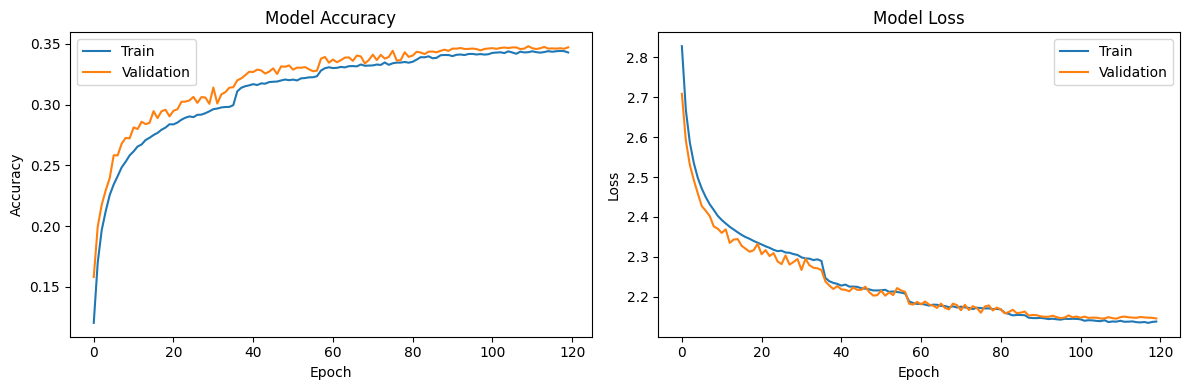

In [18]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

In [20]:


# This saves every layer's weights and biases as raw float32 binary files — same format as the ResNet `.bin` files your HLS testbench loaded. The `weights/` folder will contain files like:

# conv1d_weights.bin
# conv1d_bias.bin
# conv1d_1_weights.bin
# conv1d_1_bias.bin

# dense_weights.bin
# dense_bias.bin

os.makedirs('weights', exist_ok=True)

for layer in model.layers:
    weights = layer.get_weights()
    if len(weights) == 0:
        continue  # skip layers with no weights (pooling, dropout etc.)
    
    print(f"Exporting layer: {layer.name}")
    
    for i, w in enumerate(weights):
        name = f"weights/{layer.name}_{'weights' if i == 0 else 'bias'}.bin"
        w.astype(np.float32).tofile(name)
        print(f"  {name} — shape: {w.shape}")

print("\nAll weights exported!")

Exporting layer: conv1d
  weights/conv1d_weights.bin — shape: (3, 10, 128)
  weights/conv1d_bias.bin — shape: (128,)
Exporting layer: conv1d_1
  weights/conv1d_1_weights.bin — shape: (3, 128, 64)
  weights/conv1d_1_bias.bin — shape: (64,)
Exporting layer: conv1d_2
  weights/conv1d_2_weights.bin — shape: (3, 64, 32)
  weights/conv1d_2_bias.bin — shape: (32,)
Exporting layer: conv1d_3
  weights/conv1d_3_weights.bin — shape: (3, 32, 16)
  weights/conv1d_3_bias.bin — shape: (16,)
Exporting layer: conv1d_4
  weights/conv1d_4_weights.bin — shape: (3, 16, 8)
  weights/conv1d_4_bias.bin — shape: (8,)
Exporting layer: dense
  weights/dense_weights.bin — shape: (8, 512)
  weights/dense_bias.bin — shape: (512,)
Exporting layer: dense_1
  weights/dense_1_weights.bin — shape: (512, 256)
  weights/dense_1_bias.bin — shape: (256,)
Exporting layer: dense_2
  weights/dense_2_weights.bin — shape: (256, 128)
  weights/dense_2_bias.bin — shape: (128,)
Exporting layer: dense_3
  weights/dense_3_weights.bin